In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-02-11 18:48:17.786940: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    cache = "/Volumes/morgana2/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [4]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [5]:
source_size = 144
level = 5
# shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.wavelets.Wavelets(
    np.ones((source_size, source_size)), level=level, wavelet="db2"
)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    [],
    # cal_files[0:3],
    sci_files[0:1],
    # cal_files,
    # sci_files,
    # [],
    state=state,
    modeller=dorito.models.WaveletModel,
    ramp_model=ode_ramp,
    extra_priors={
        "approx": np.log10(wavelets.approx),
        "details": wavelets.values,
        # "log_distribution": np.log10(
        #     np.ones((source_size, source_size)) / source_size**2
        # ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    wavelets=wavelets,
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.WaveletFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
for p in [
    "positions",
    # "fluxes",
    "aberrations",
    # "log_distribution",
]:
    params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

No Teff found for IO, defaulting to 4500K


In [6]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

  0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
def normalise_wavelets(model, model_params, args, key):
    params = model_params.params

    if "approx" not in params.keys() or "details" not in params.keys():
        return model_params, key

    for approx, details in zip(params["approx"].items(), params["details"].items()):

        k_a, approx = approx
        k_d, details = details

        wavelets = model.wavelets
        wavelets = wavelets.set(["approx", "values"], [10**approx, details])

        # normalising the wavelets so distribution adds to unity
        wavelets = wavelets.normalise()

        # setting the parameters to normalised versions
        params["approx"][k_a] = np.log10(wavelets.approx)

        if "mask" in args:
            mask = args["mask"]
            params["details"][k_d] = wavelets.values.at[mask].set(0.0)

        else:
            params["details"][k_d] = wavelets.values

    return model_params.set("params", params), key


def wavelet_grad_fn(model, grads, args, key):
    if "mask" not in args.keys():
        raise KeyError("Mask not provided")
        # return grads, key

    # if grads.details is None:
    #     return grads, key

    # grabbing mask to zero out grads
    mask = args["mask"]

    # getting the details dictionary
    deets_dict = grads.details

    # looping over exposures and zeroing out masked values
    for k, details in deets_dict.items():

        if details is None:
            print("Details is None")
            continue

        details = details.at[mask].set(0.0)
        deets_dict[k] = details

    # setting the details dictionary to the zeroed out version
    return grads.set("details", deets_dict), key


# def L1_on_wavelets(model, exposure, args):
#     details = model.details[exposure.get_key("details")]
#     approx = model.approx[exposure.get_key("approx")]

#     total = np.hstack([details, 10 ** approx.flatten()])
#     return dorito.stats.L1_loss(total)


def L1_on_wavelets(model, exposure, args):

    # getting flux and wavelets
    flux = model.fluxes[exposure.get_key("fluxes")]
    wavelets = exposure.update_wavelets(model)

    # scaling distribution by flux
    scaled_dist = flux * wavelets.distribution

    # converting scaled distribution to approx and details again
    # approx is not logged here
    APPROX, detail_tree = wavelets.wavelet_transform(scaled_dist)
    details = wavelets.flatten_details(detail_tree)

    # combining, approx is not logged
    total = np.hstack([details, APPROX.flatten()])

    # calculating L1 loss
    return dorito.stats.L1_loss(total)

In [8]:
# img = np.zeros((source_size, source_size))
# wl = dorito.wavelets.Wavelets(
#     img,
#     level=6,
# )

# d = 3
# d1 = 2 * d - 1
# d2 = 4 * d - 3
# n = 3
# s = 20
# s1 = 2 * s - 2
# s2 = 4 * s - 7

# # wavelets = final_wavelets

# # print(wavelets)

# mask = np.concatenate(
#     (
#         *[
#             (i * s**2 + np.arange((s - d) * s, (s + d) * s)) % (n * s**2)
#             for i in range(0, 3)
#         ],
#         *[
#             n * s**2
#             + (i * s1**2 + np.arange((s1 - d1) * s1, (s1 + d1) * s1)) % (n * s1**2)
#             for i in range(0, 3)
#         ],
#         *[
#             n * (s**2 + s1**2)
#             + (i * s2**2 + np.arange((s2 - d2) * s2, (s2 + d2) * s2)) % (n * s2**2)
#             for i in range(0, 3)
#         ],
#         *[np.arange(i, n * s**2, s) for i in range(-d, d)],
#         *[n * s**2 + np.arange(i, n * s1**2, s1) for i in range(-d1, d1)],
#         *[n * (s**2 + s1**2) + np.arange(i, n * s2**2, s2) for i in range(-d2, d2)],
#     )
# )

# new_deets = wavelets.values.at[mask].set(1)
# print(wl.values.shape)
# wl = wavelets.set("values", new_deets)
# print(wl.values.shape)

# # new_deets = wavelets.values.at[~mask].set(-2.0)
# # wl = wavelets

# dorito.plotting.tree_plot(wl.coeffs, lvl=wavelets.level)

In [14]:
n_epoch = 300

config = {
    # "positions": sgd(2e-1, 0),
    "fluxes": sgd(5e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    # "fluxes": sgd(2e-2, 0),
    # "log_distribution": adam(2e-2, 5),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "approx": adam(1e-5, 0),
    "approx": adam(6e-3, 8),
    "details": adam(6e-9, 15),
    # "approx": adam(2e-2, 8),
    # "details": adam(2e-8, 15),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    "L1": 2.0e3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        "L1": L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    # norm_fn=dorito.stats.normalise_wavelets,
    norm_fn=normalise_wavelets,
    # norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    # grad_fn=wavelet_grad_fn,
    epochs=n_epoch,
    print_grads=False,
    eps=1e-2,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/300 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:04
Initial Loss: 49,958.40
Est time per epoch:  0:00:00
Est run time:  0:00:42
Full Time: 0:00:53
Final Loss: 1,470.20


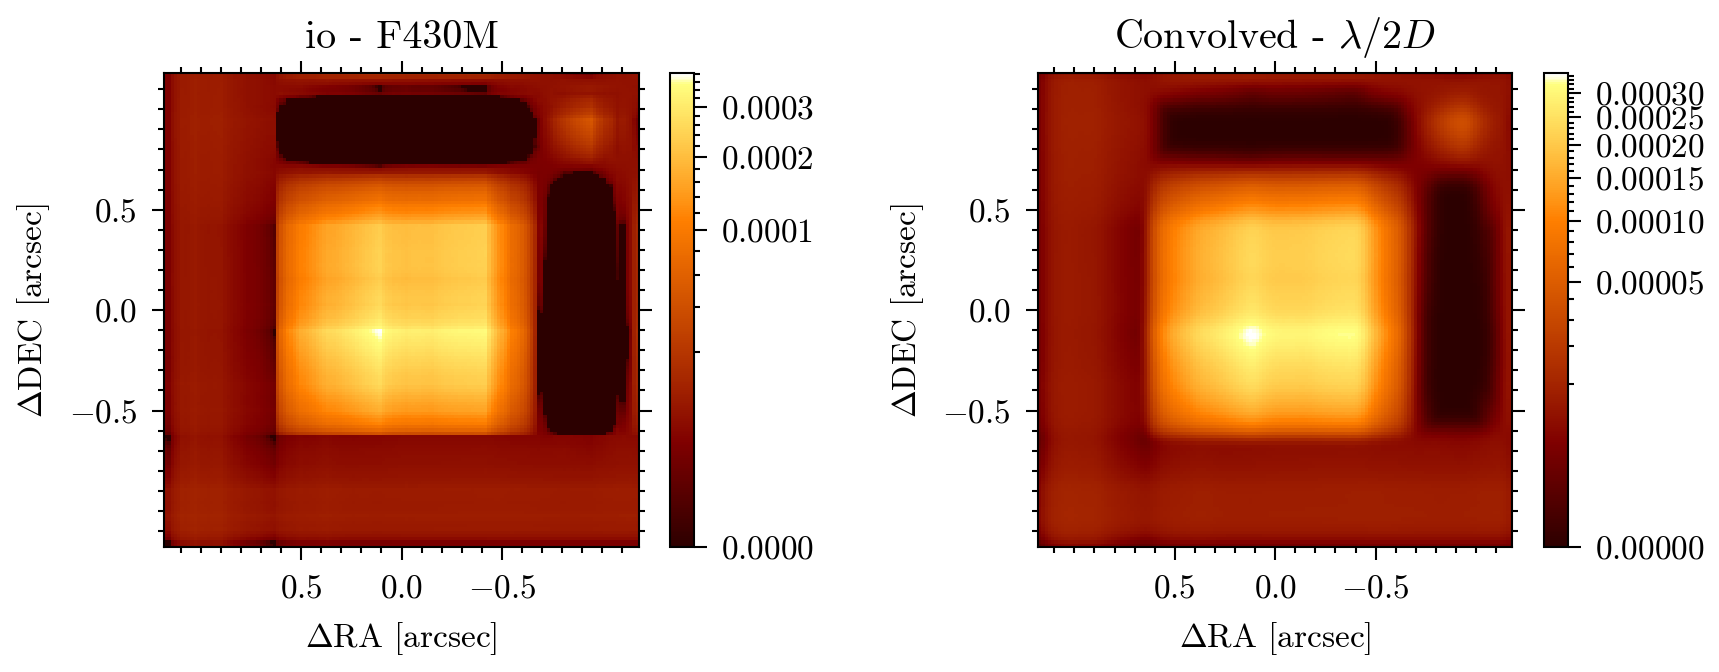

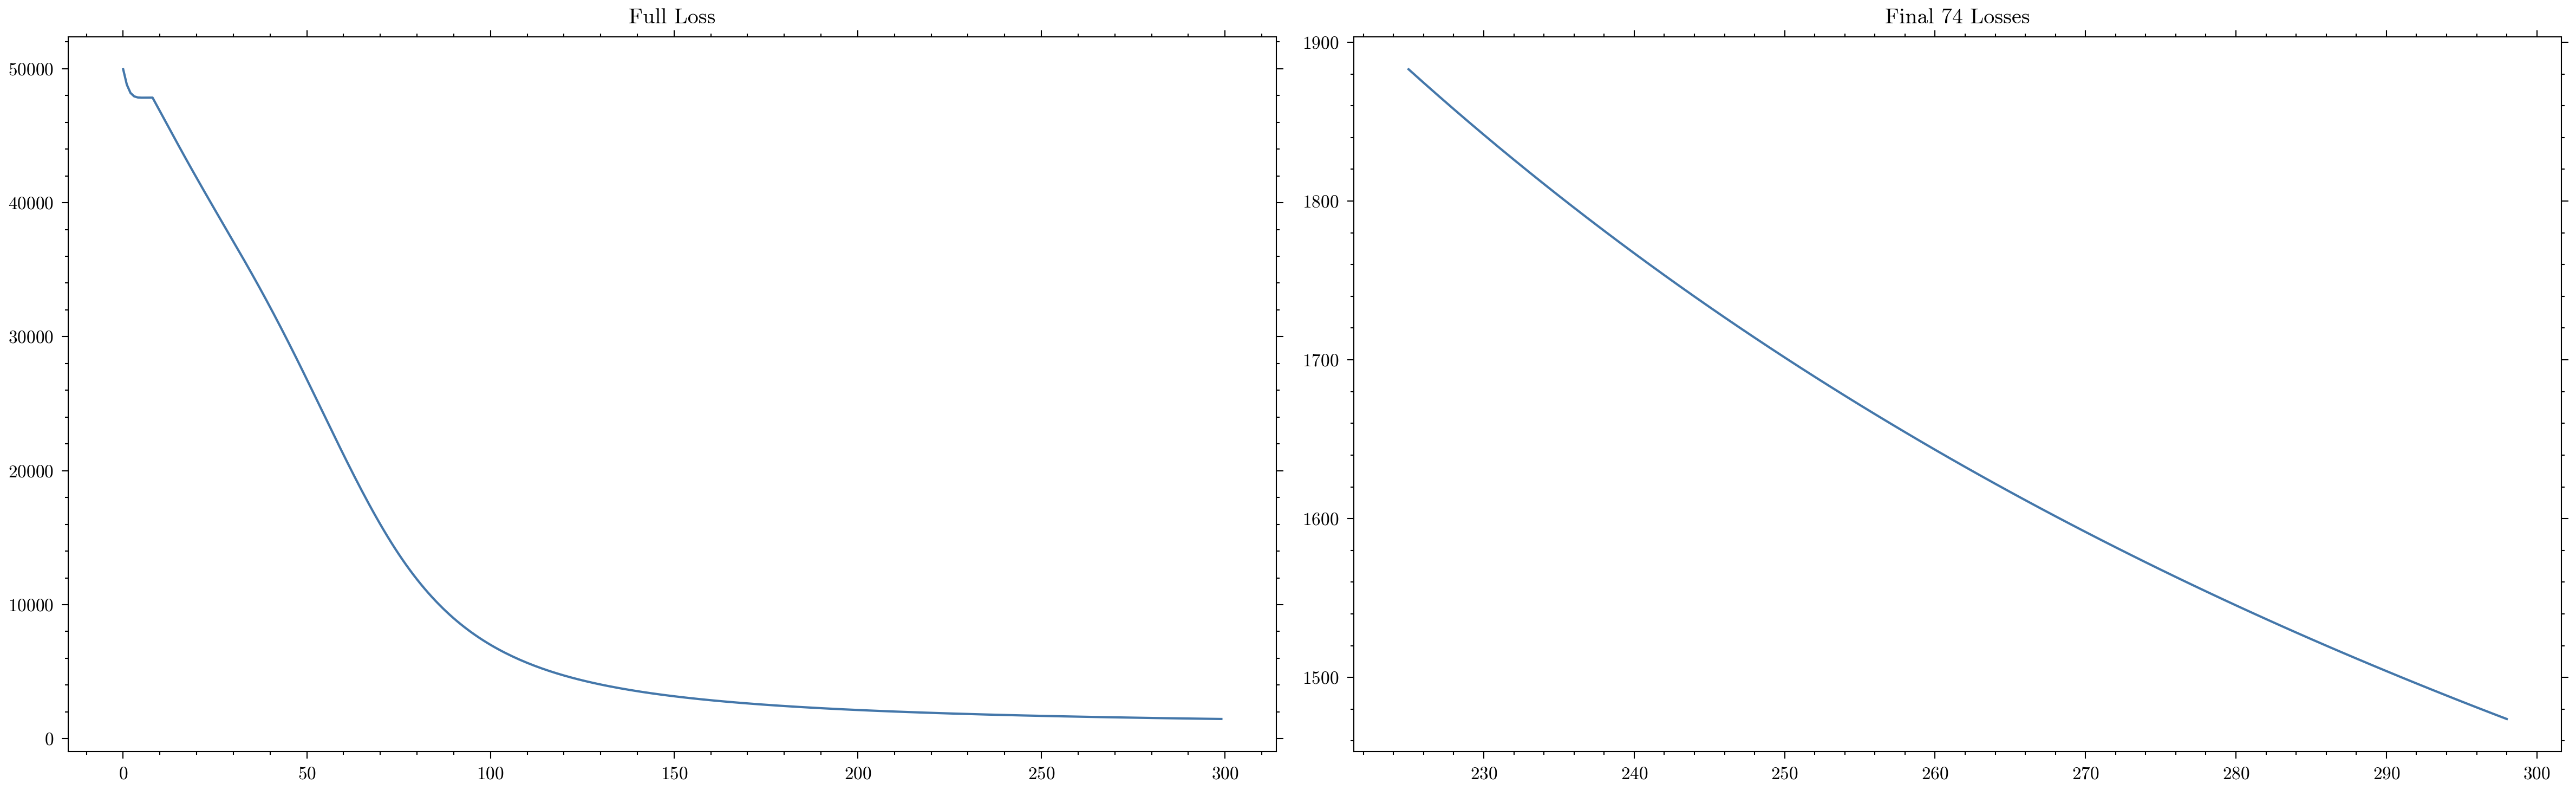

/home/max/code/amigo/src/amigo/plotting.py:325: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


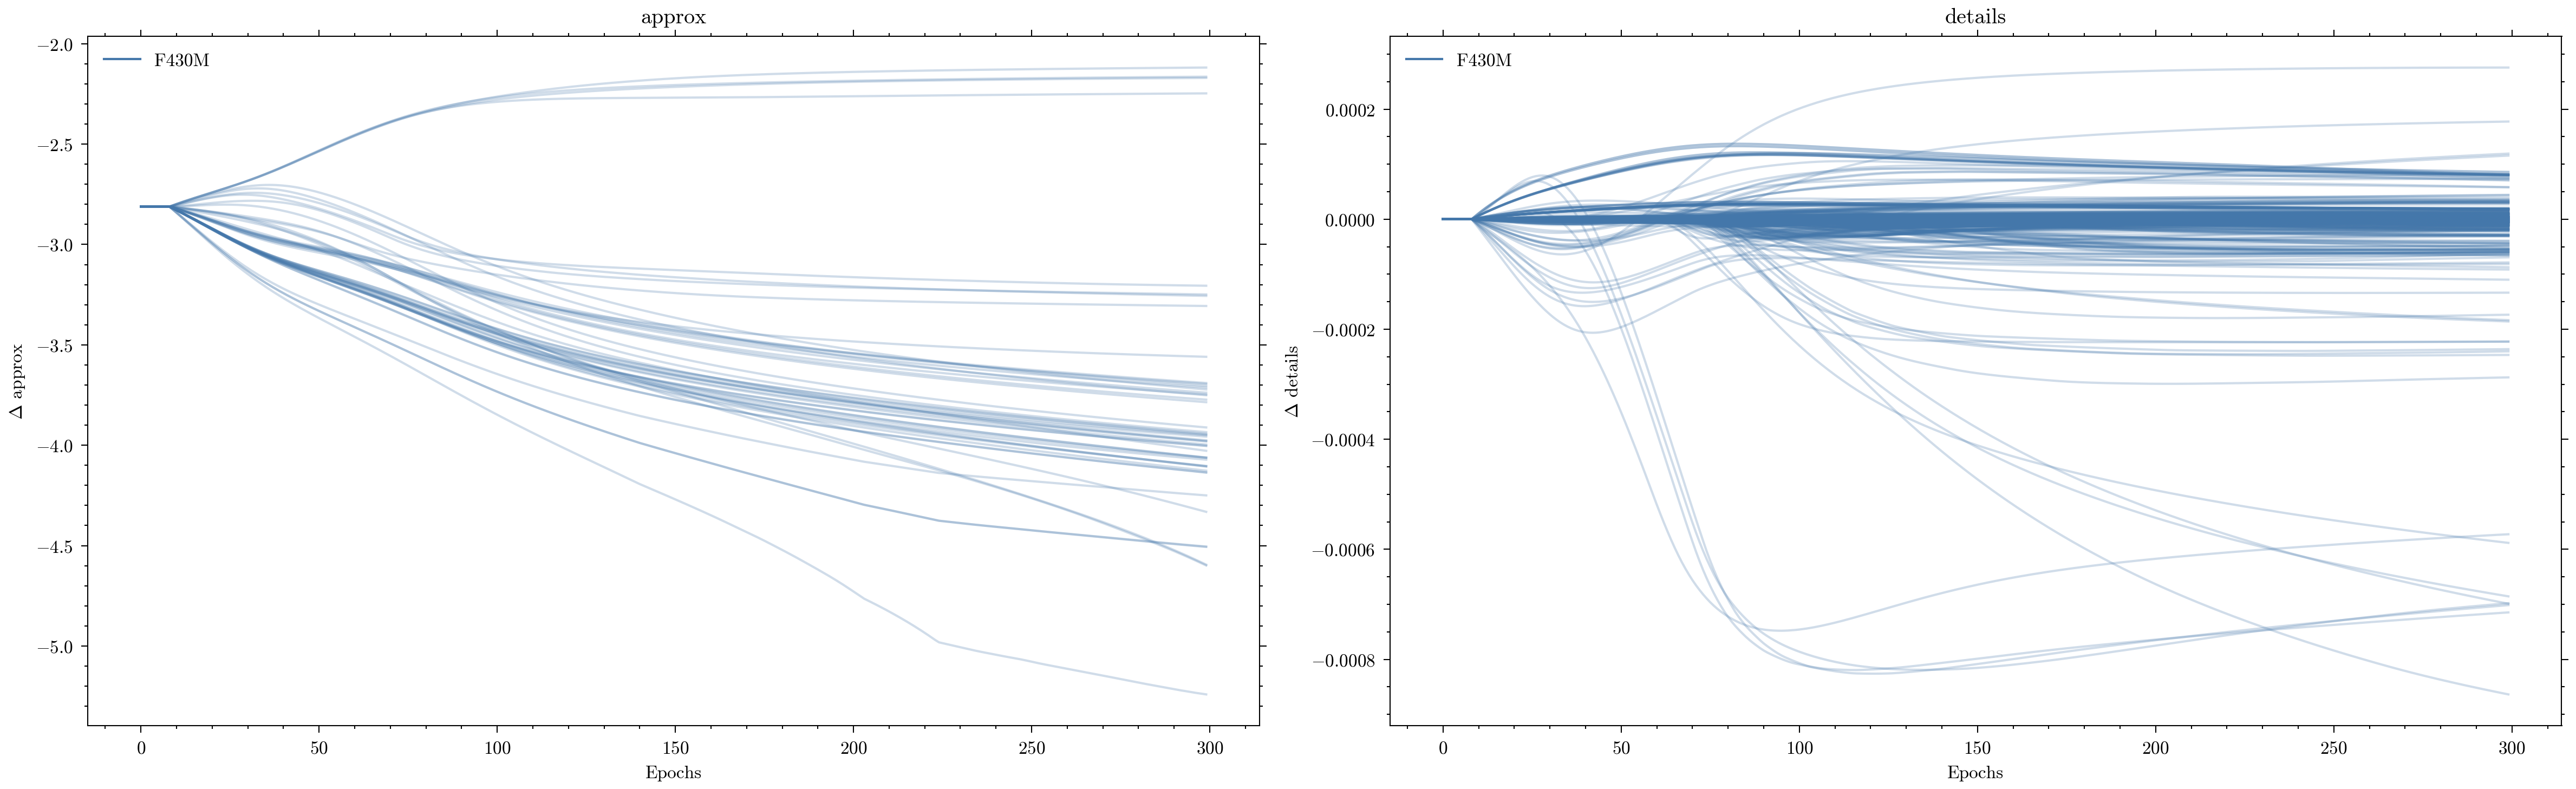

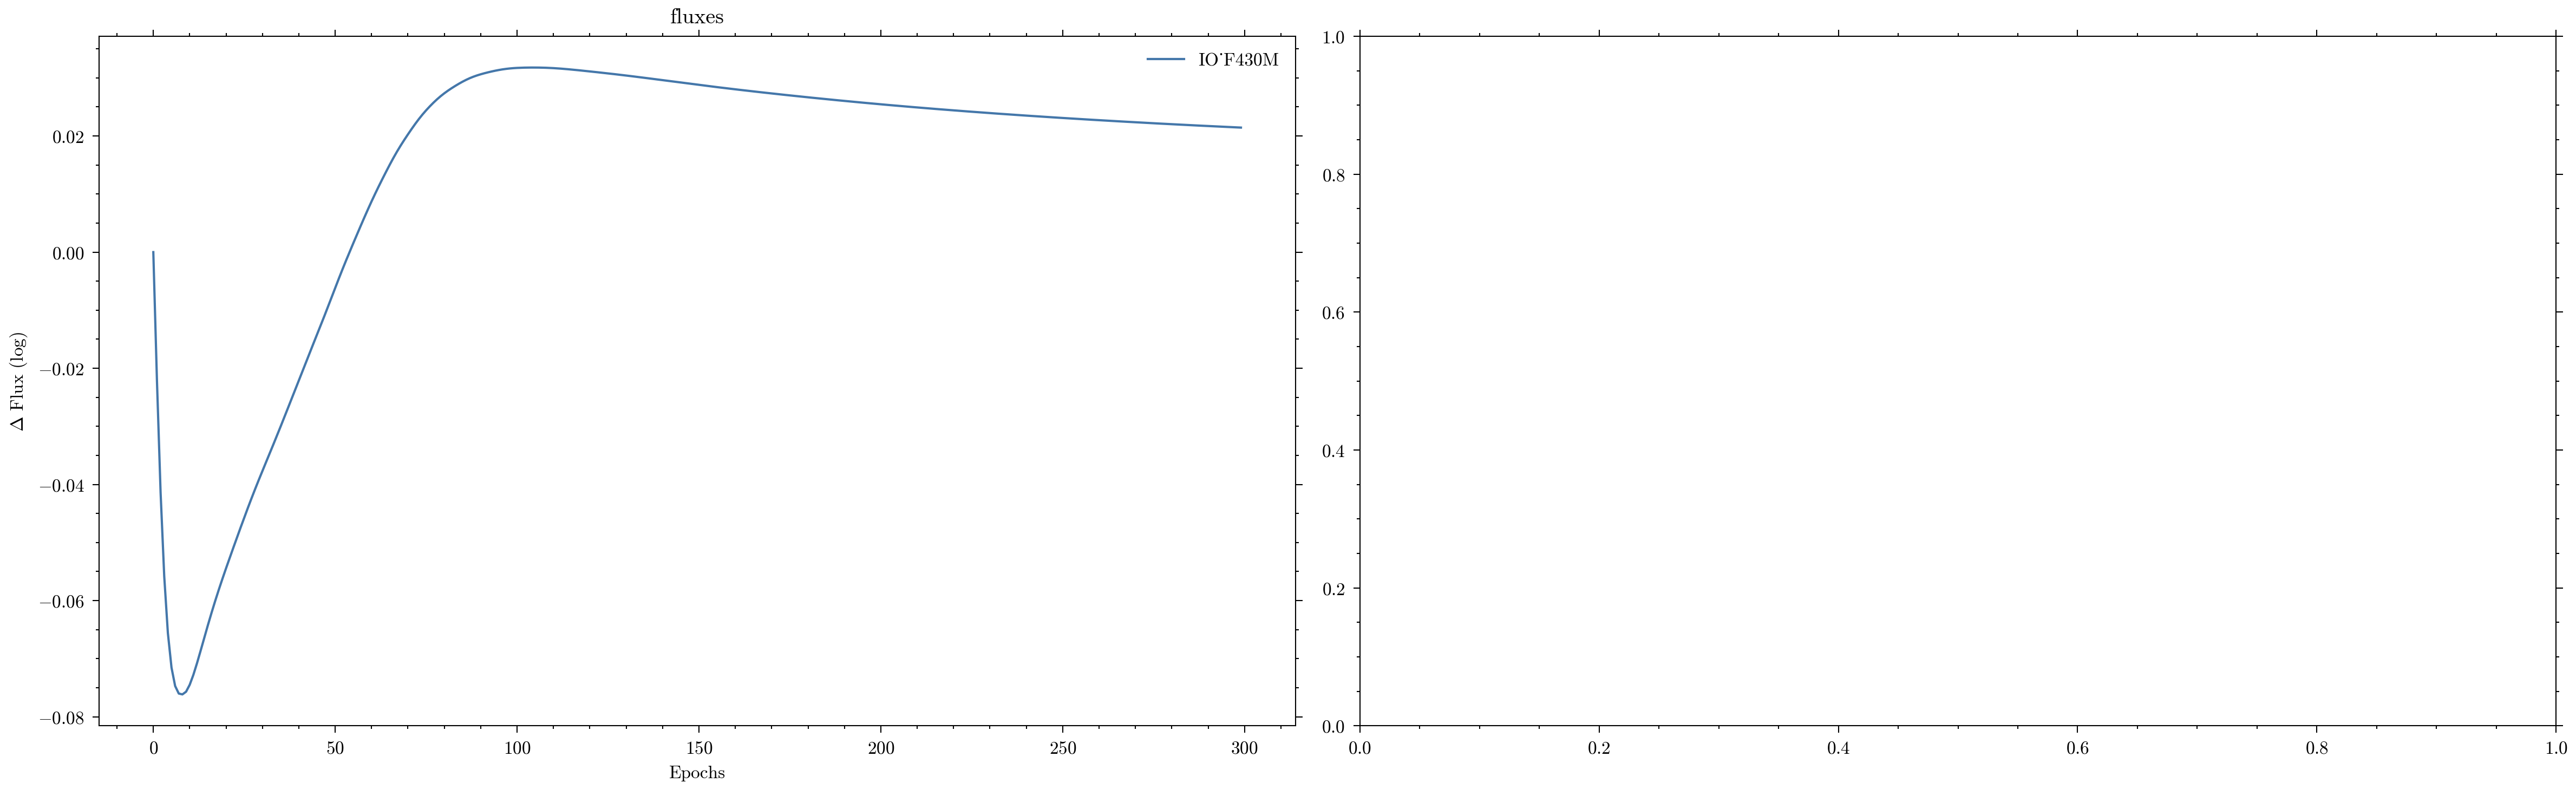

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



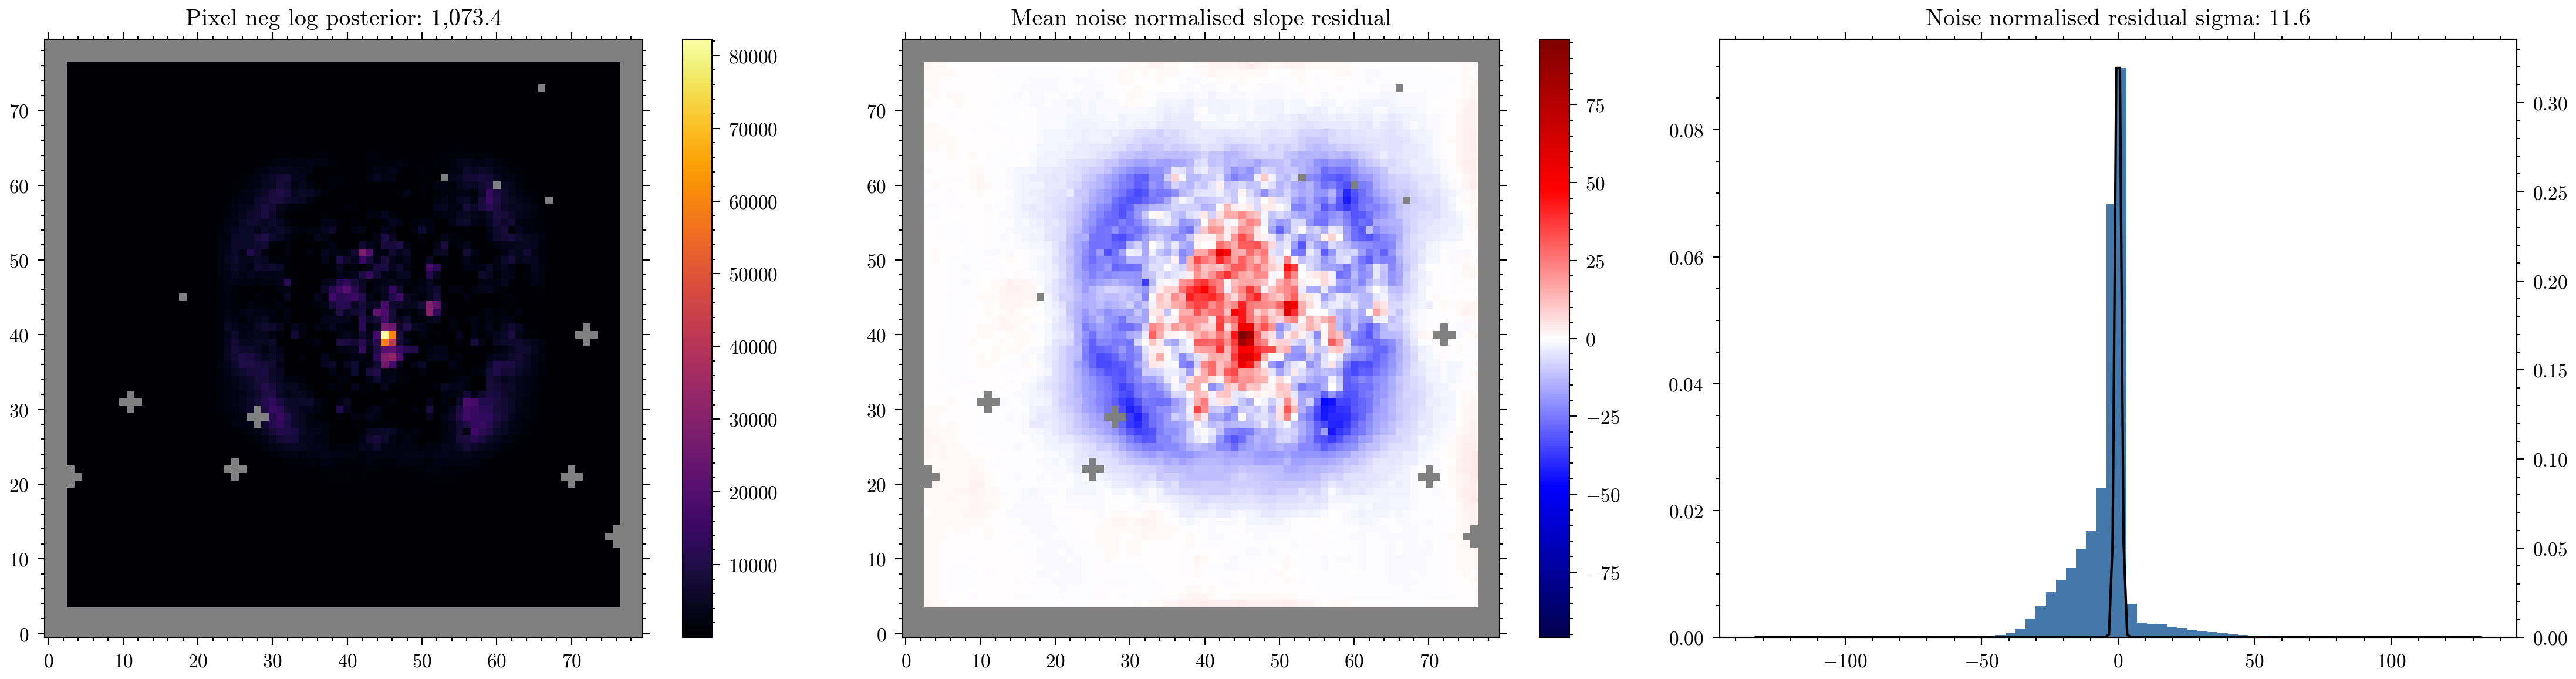

In [15]:
# np.save(init_state_cache + "F430M.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            try:
                dist = final_model.get_distribution(exp)
            except:
                dist = exp.get_distribution(final_model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                # roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                # roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"io - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

final_wavelets = fits[0].update_wavelets(final_model)
final_wavelets.distribution

# scaling distribution by flux
scaled_dist = (
    final_model.fluxes[fits[0].get_key("fluxes")] * final_wavelets.distribution
)

# # converting scaled distribution to approx and details again
# # approx is not logged here


# APPROX, detail_tree = final_wavelets.wavelet_transform(scaled_dist)
# final_wavelets = final_wavelets.set(
#     ["approx", "values"], [np.log10(APPROX), detail_tree]
# )
# print(final_wavelets)
# wavelet_plot([np.log10(APPROX), *final_wavelets.build], level=final_wavelets.level)

dorito.plotting.tree_plot(final_wavelets.coeffs)

amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )

In [11]:
sweep, coeffs, log_dists = dorito.stats.lcurve_sweep(
    "L1",
    np.logspace(-1, 4, 10),
    model,
    fits,
    args,
    config,
    fishers,
    norm_fn=normalise_wavelets,
    grad_fn=wavelet_grad_fn,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=500,
    eps=1e-2,
)

  0%|          | 0/500 [00:00<?, ?it/s]

Grad Batch fn compiling...


KeyError: 'Mask not provided'

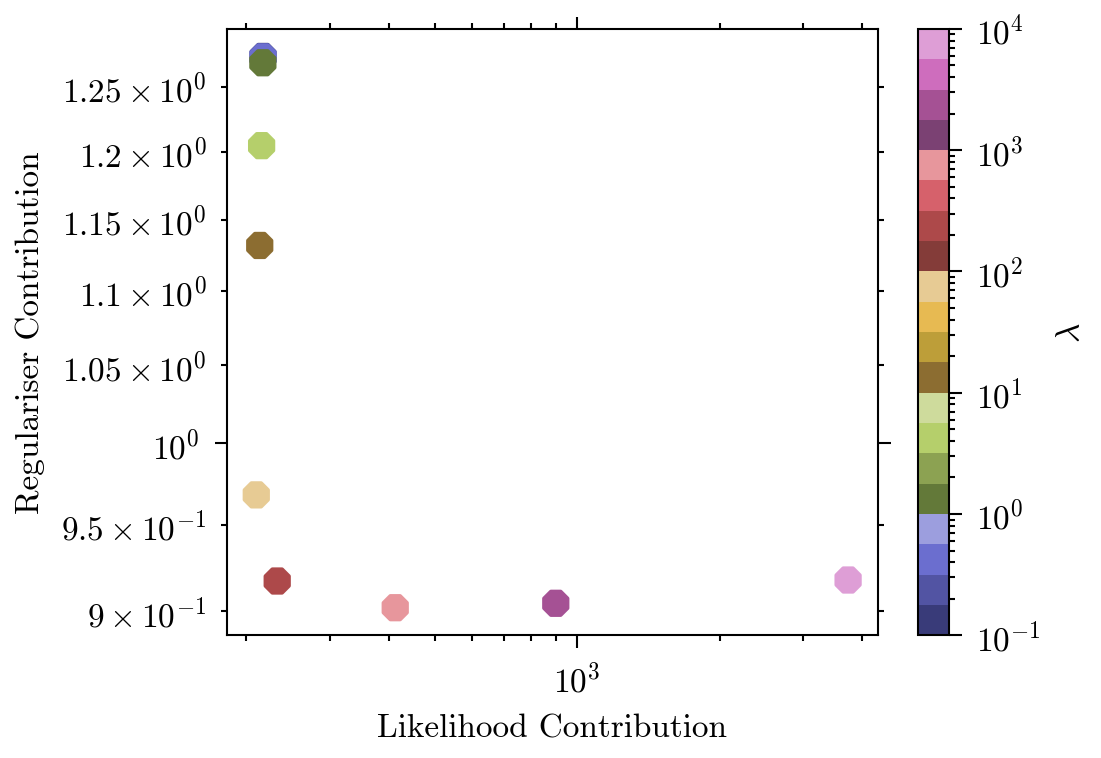

In [ ]:
plt.figure()
plt.scatter(
    sweep[0],
    sweep[1],
    c=coeffs,
    cmap="tab20b",
    # cmap="viridis",
    norm=mpl.colors.LogNorm(),
    marker="8",
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label=r"$\lambda$")
plt.xlabel("Likelihood Contribution")
plt.ylabel("Regulariser Contribution")
plt.show()

In [ ]:
coeffs

Array([1.00000000e-01, 3.59381366e-01, 1.29154967e+00, 4.64158883e+00,
       1.66810054e+01, 5.99484250e+01, 2.15443469e+02, 7.74263683e+02,
       2.78255940e+03, 1.00000000e+04], dtype=float64)

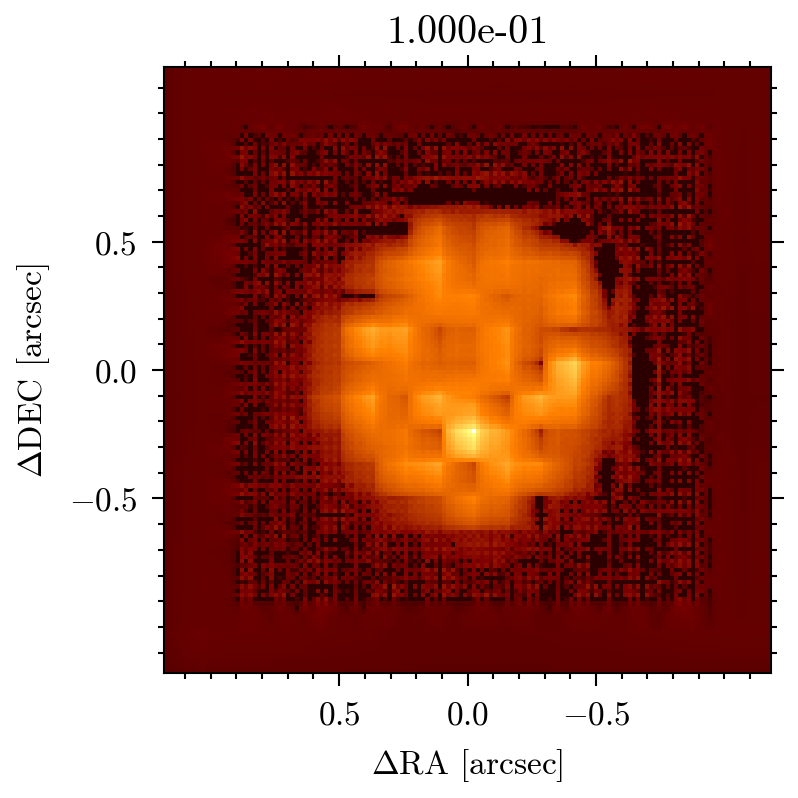

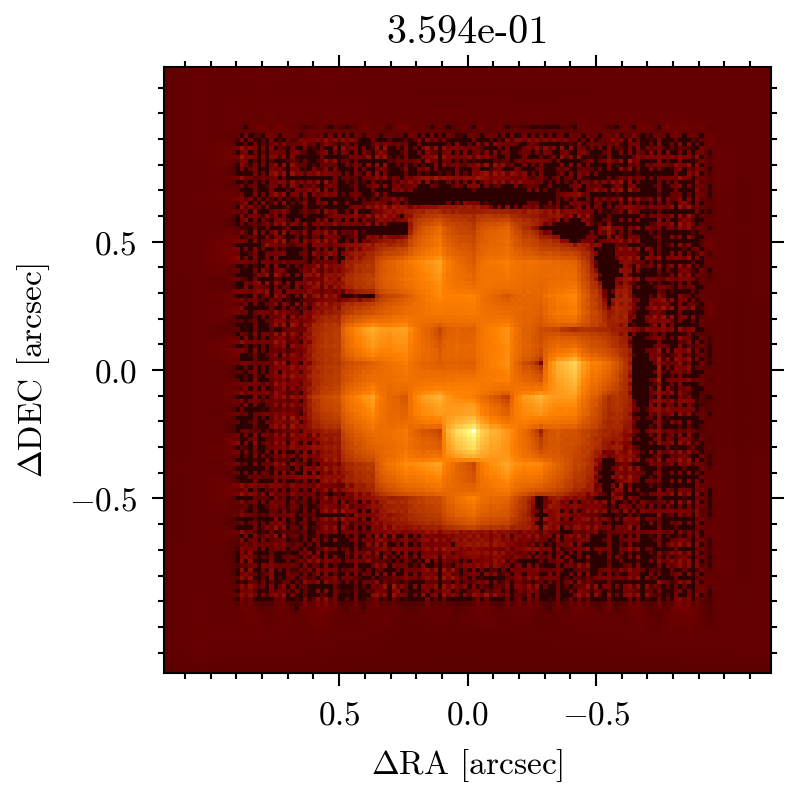

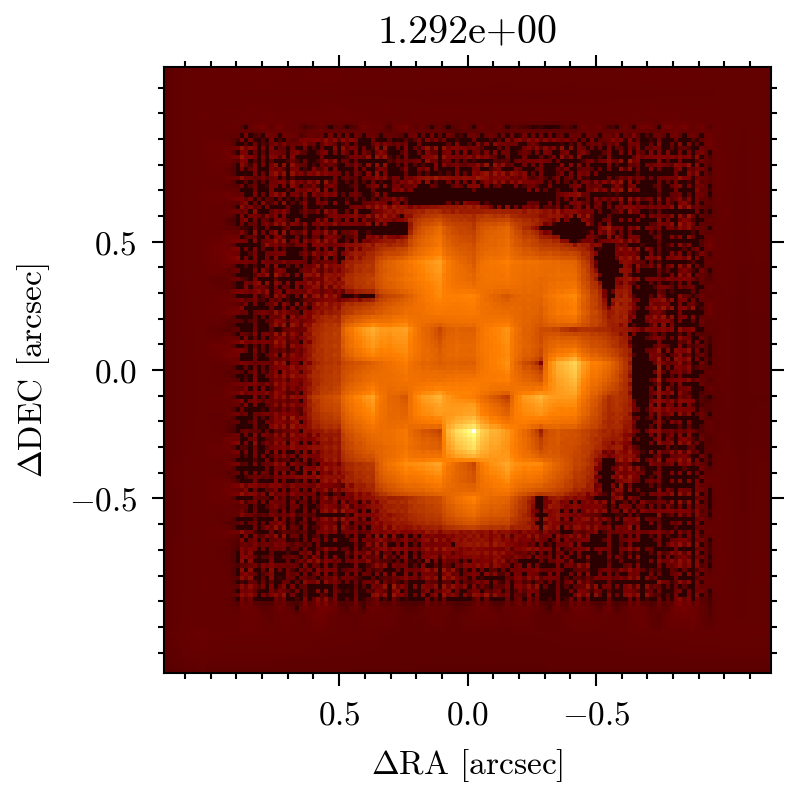

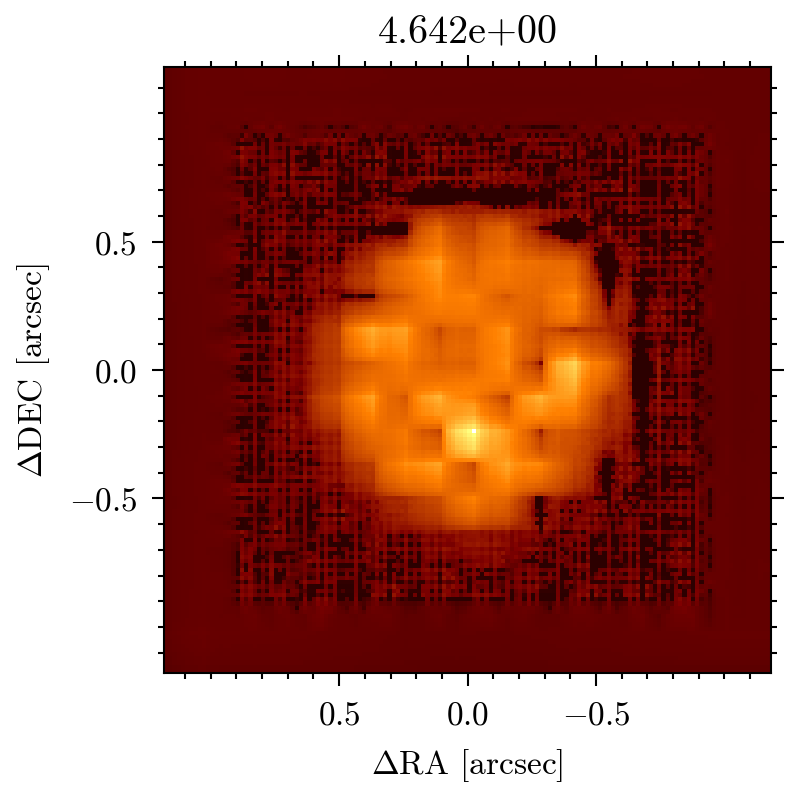

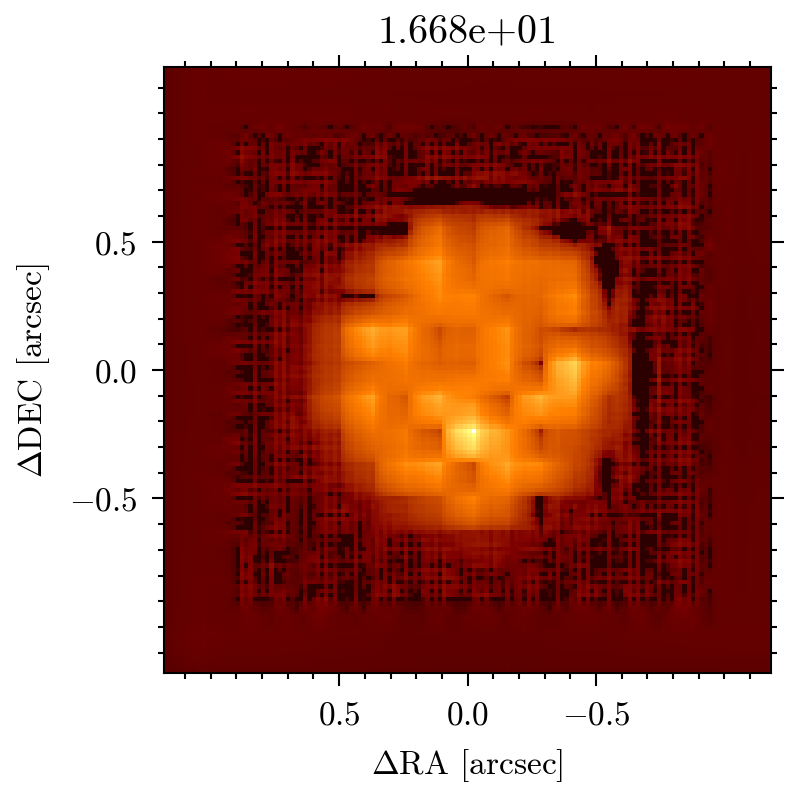

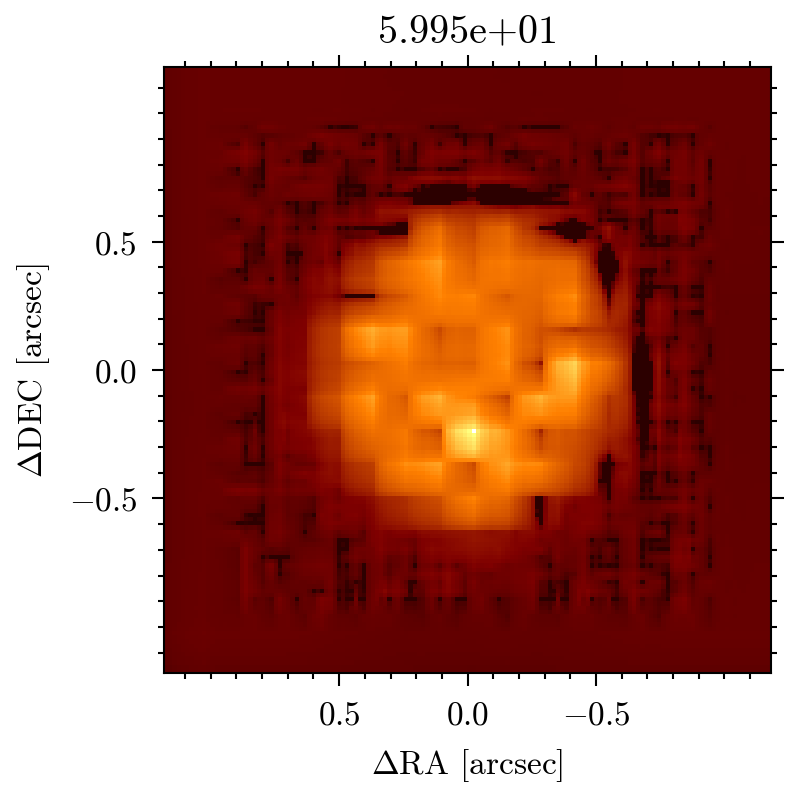

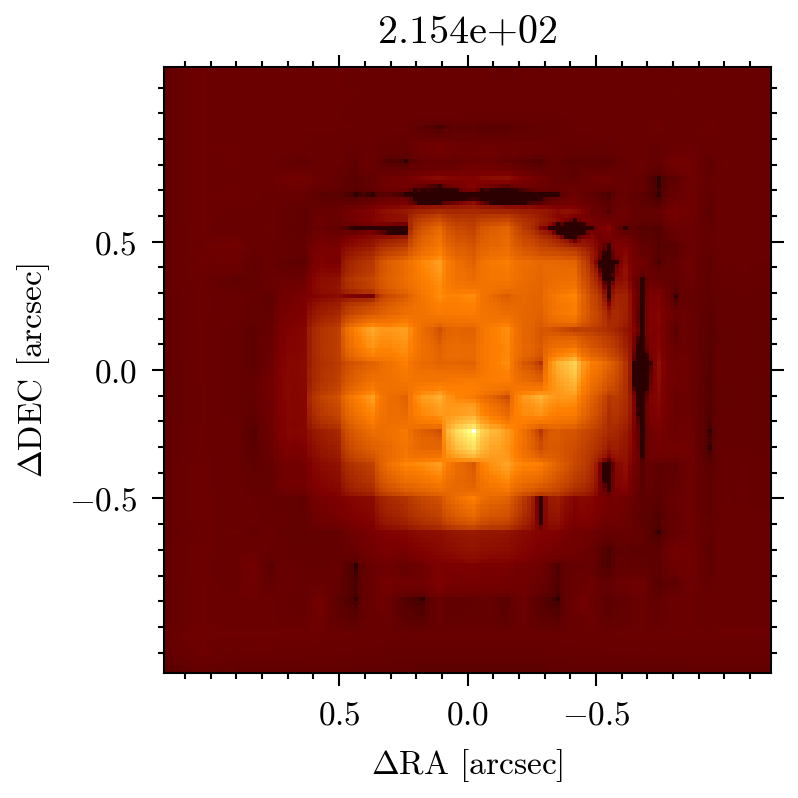

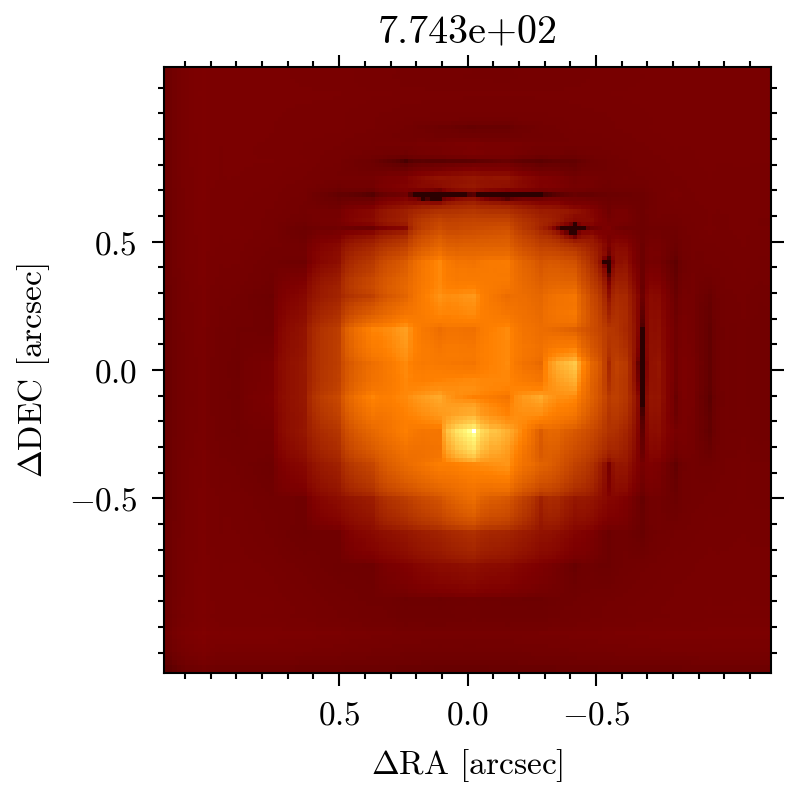

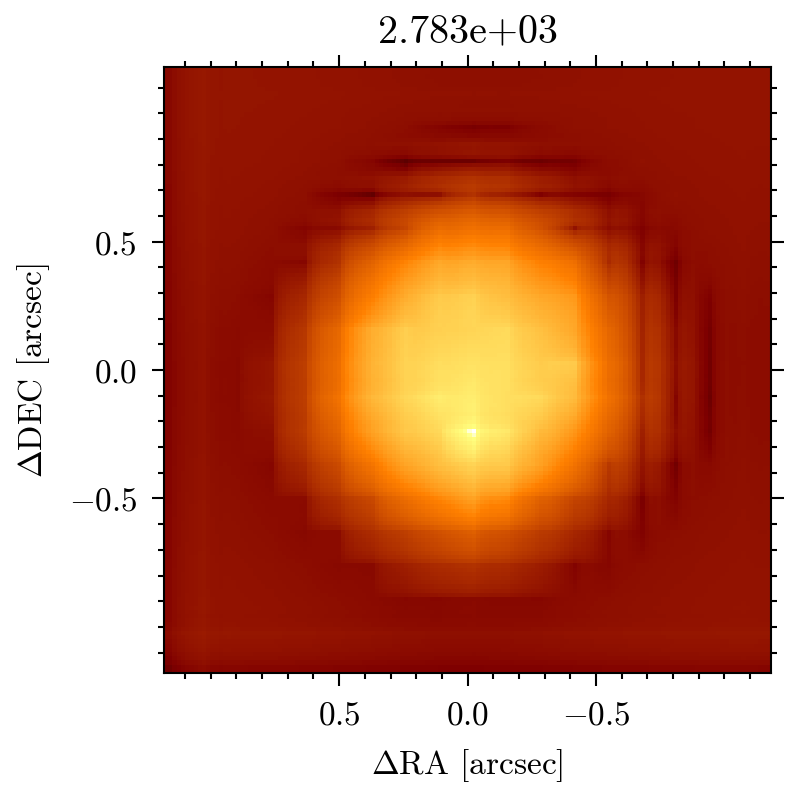

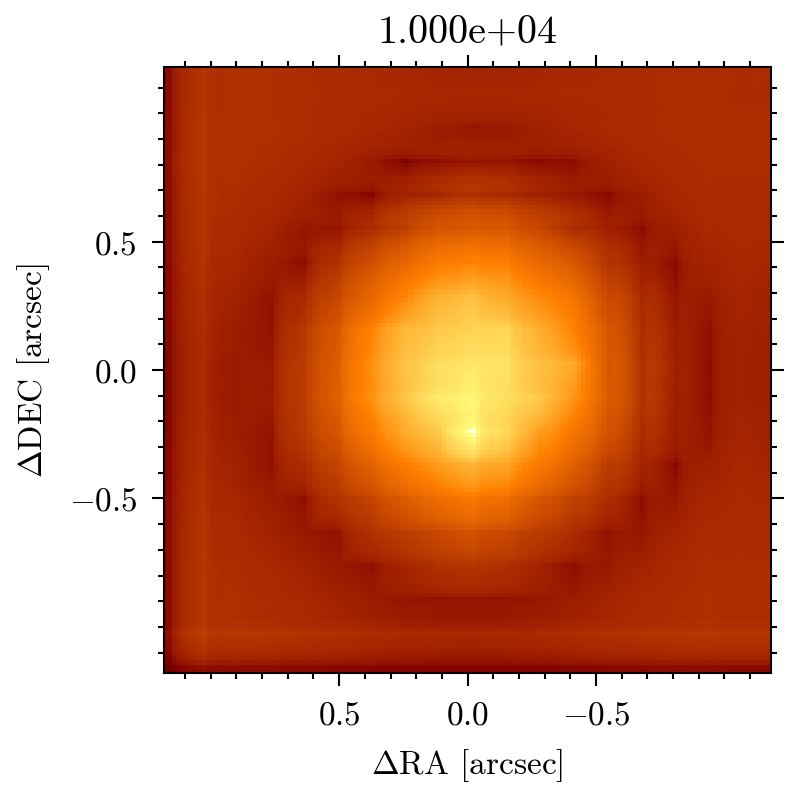

In [ ]:
for i, l in enumerate(log_dists):
    # plt.imshow(10 ** l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    fig, ax = plt.subplots(1, 1)
    c0 = dorito.plotting.plot_result(
        ax,
        # 10 ** l["F480M"],
        l,
        # roll_angle_degrees=-rolls[fits[0].filename],
        cmap="afmhot_10u",
        power=0.3,
        # model=final_model,
        # vmin=None,
        # show_diff_lim=True,
        # vmax=io_peak_flux,
    )
    plt.title(f"{coeffs[i]:.3e}")
    plt.show()